# Infidelity Minimisation with `op.Infidelity`

This notebook demonstrates how to use `jVMC_exp.operator.discrete.Infidelity` together with `jVMC_exp.util.util.matrix_to_jvmc_operator`.

The example is structured as follows:

1. Build an exact reference ground state for a small transverse-field Ising chain.
2. Convert a dense two-site matrix into a jVMC operator with `matrix_to_jvmc_operator`.
3. Verify the operator conversion with an exact infidelity test.
4. Optimise a variational state with `op.Infidelity`.
5. Compare the estimator against the exact overlap at the end.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optax
import jax.numpy as jnp
import tqdm

import jVMC_exp
import jVMC_exp.nets as nets
import jVMC_exp.operator.discrete as op
from jVMC_exp.stats import SampledObs
from jVMC_exp.util.util import matrix_to_jvmc_operator
from jVMC_exp.vqs import NQS

Running in single-node mode (JVMC_USE_DISTRIBUTED not set)


## Build the Reference State

We use a length-6 transverse-field Ising chain and obtain its exact ground state from dense diagonalisation. The helper `embed_local_operator` is only used to build the dense reference Hamiltonian and to embed a two-site matrix into the full Hilbert space for later validation.


In [2]:
sx = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
sz = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)


def embed_local_operator(local_matrix, site, system_size, nsites=1):
    if site == 0:
        return np.kron(local_matrix, np.identity(2 ** (system_size - nsites), dtype=complex))
    return np.kron(
        np.identity(2 ** site, dtype=complex),
        np.kron(local_matrix, np.identity(2 ** (system_size - site - nsites), dtype=complex)),
    )


def create_tfim_hamiltonian(g, J, system_size):
    transverse = embed_local_operator(sx, 0, system_size)
    for site in range(1, system_size):
        transverse += embed_local_operator(sx, site, system_size)

    interaction = (
        embed_local_operator(sz, 0, system_size) @ embed_local_operator(sz, 1, system_size)
        + embed_local_operator(sz, system_size - 1, system_size) @ embed_local_operator(sz, 0, system_size)
    )
    for site in range(1, system_size - 1):
        interaction += embed_local_operator(sz, site, system_size) @ embed_local_operator(sz, site + 1, system_size)

    return -0.5 * (g * transverse - J * interaction)


L = 6
J = 1.0
g = 0.5

eigenvalues, eigenvectors = np.linalg.eigh(create_tfim_hamiltonian(g, J, L))
ground_state = np.abs(eigenvectors[:, 0])
ground_state = ground_state / np.linalg.norm(ground_state)

print(f"Ground-state energy: {eigenvalues[0]:.8f}")
print(f"Hilbert-space dimension: {2 ** L}")

Ground-state energy: -3.19234728
Hilbert-space dimension: 64


## Convert a Dense Two-Site Matrix into a jVMC Operator

Next we create a random two-site unitary, convert it with `matrix_to_jvmc_operator`, and keep both the operator and its conjugate. We also embed the same dense matrix into the full Hilbert space so that later comparisons can be performed directly in the computational basis.

The same helper also supports single-site operators: passing a `2 x 2` matrix together with `sites=(i,)` returns the corresponding one-site jVMC operator acting on site `i`.


In [3]:
def haar_unitary(n, rng):
    ginibre = (rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))) / np.sqrt(2.0)
    q, r = np.linalg.qr(ginibre)
    phases = np.diag(r) / np.abs(np.diag(r))
    return q * phases.conj()


def random_unitary(n=4, eps=0.2, seed=1234):
    rng = np.random.default_rng(seed)
    basis_change = haar_unitary(n, rng)
    generator_eigs = rng.uniform(-eps, eps, size=n)
    hermitian = basis_change @ np.diag(generator_eigs) @ basis_change.conj().T
    w, v = np.linalg.eigh(hermitian)
    return v @ np.diag(np.exp(-1j * w)) @ v.conj().T


sites = (0, 1)
unitary_local = random_unitary(n=4, eps=1.0, seed=452)
unitary_jvmc, conjugate_unitary_jvmc = matrix_to_jvmc_operator(
    unitary_local,
    sites,
    return_conjugate=True,
)
unitary_dense = embed_local_operator(unitary_local, site=0, system_size=L, nsites=2)

print(f"Local operator is unitary: {np.allclose(unitary_local.conj().T @ unitary_local, np.eye(4))}")

Local operator is unitary: True


## Test 1: Verify `matrix_to_jvmc_operator` with Exact Sampling

This first test checks that the converted jVMC operator acts like the original dense matrix. We create

- a reference state `chi` containing the Ising ground state,
- a transformed state `chi_transformed = U |chi\rangle` built from the dense matrix,
- an `op.Infidelity` estimator configured with the converted operator pair.

For an exact conversion, the infidelity between `chi_transformed` and `U |chi\rangle` should be numerically zero.


In [4]:
reference_model = nets.FullConfigurationState(L=L, d=2)
chi = NQS(reference_model, L, batchSize=2 ** L)
chi.parameters = jnp.array(ground_state)
chi_sampler = jVMC_exp.sampler.ExactSampler(chi)

transformed_state = unitary_dense @ ground_state
transformed_state /= np.linalg.norm(transformed_state)

chi_transformed = NQS(reference_model, L, batchSize=2 ** L)
chi_transformed.parameters = jnp.array(transformed_state)
chi_transformed_sampler = jVMC_exp.sampler.ExactSampler(chi_transformed)

loss_function = jVMC_exp.objective_function.Infidelity(
    reference_sampler=chi_sampler,
    operator=unitary_jvmc, 
    conjugated_operator=conjugate_unitary_jvmc
)

infidelity = loss_function(chi_transformed_sampler)
infidelity_mean = infidelity.mean.real.item()

print(f"Infidelity after dense-to-jVMC conversion: {infidelity_mean}")
print(f"Conversion test passed: {np.allclose(infidelity_mean, 0.0)}")

W0417 10:58:57.096994  135435 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Infidelity after dense-to-jVMC conversion: -1.9598087666759453e-15
Conversion test passed: True


## Optimise a Trial State with `op.Infidelity`

We now minimise the infidelity of a variational RBM against the transformed target state `U |chi\rangle`. The target `chi` itself remains unchanged; the operator pair supplied to `op.Infidelity` defines the transformed comparison.

To keep the notebook lightweight, we use a short Monte Carlo optimisation loop and record the infidelity estimate at every step.


In [5]:
num_hidden = 2**6
num_iterations = 200
num_samples = 2**9
num_chains = 2**7
learning_rate = 5e-4

trial_model = nets.CpxRBM(numHidden=num_hidden, bias=True)
psi = NQS(trial_model, L, batchSize=num_samples)

optimizer = optax.adam(learning_rate=learning_rate)
optimizer_state = optimizer.init(psi.parameters_flat)

proposer = jVMC_exp.propose.SpinFlip()
chi_sampler = jVMC_exp.sampler.MCSampler(chi, proposer, 123, num_chains, num_samples)
psi_sampler = jVMC_exp.sampler.MCSampler(psi, proposer, 123, num_chains, num_samples)

loss_function = jVMC_exp.objective_function.Infidelity(
    reference_sampler=chi_sampler,
    operator=unitary_jvmc, 
    conjugated_operator=conjugate_unitary_jvmc,
    control_variate='Simple'
)

infidelity_history = np.zeros(num_iterations)

for step in tqdm.tqdm(range(num_iterations)):
    psi_sampler.sample()
    out = loss_function.value_and_grad(psi_sampler)
    infidelity_history[step] = out.o_loc.mean.real.item()

    parameters = psi.parameters_flat
    updates, optimizer_state = optimizer.update(
        out.grad.mean.reshape(parameters.shape).real,
        optimizer_state,
        parameters,
    )
    psi.parameters = optax.apply_updates(parameters, updates)

print(f"Initial estimated infidelity: {infidelity_history[0]:.6f}")
print(f"Final estimated infidelity:   {infidelity_history[-1]:.6f}")


100%|██████████| 200/200 [00:09<00:00, 21.12it/s]

Initial estimated infidelity: 0.900107
Final estimated infidelity:   0.053679


## Test 2: Compare the Final Estimator to the Exact Overlap

After optimisation we validate the result in two ways:

- the optimisation trace should decrease overall,
- the final `op.Infidelity` estimate obtained with exact sampling should agree with the exact overlap computed from dense state vectors.

This provides a direct end-to-end check of both `matrix_to_jvmc_operator` and `op.Infidelity` in a realistic workflow.


In [8]:
reference_state.shape, psi_state.shape

((64,), (512,))

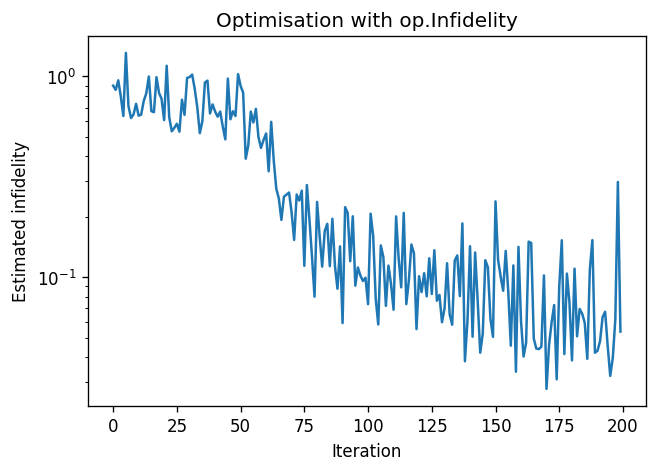

ValueError: cannot reshape array of size 512 into shape (64,)

In [6]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(np.arange(num_iterations), np.abs(infidelity_history))
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Estimated infidelity")
ax.set_title("Optimisation with op.Infidelity")
plt.show()

exact_sampler = jVMC_exp.sampler.ExactSampler(psi)

exact_validation = jVMC_exp.objective_function.Infidelity(
    chi_sampler, unitary_jvmc, conjugate_unitary_jvmc 
)

infidelity = exact_validation(psi_sampler)

estimated_final_infidelity = infidelity.mean.real.item()

psi_state = np.exp(np.asarray(psi_sampler.logPsi).reshape(-1))
psi_state = psi_state / np.linalg.norm(psi_state)
reference_state = transformed_state / np.linalg.norm(transformed_state)
exact_overlap_infidelity = float(np.real(1.0 - np.abs(np.vdot(reference_state, psi_state)) ** 2))

print(f"Final exact-sampling estimator: {estimated_final_infidelity:.12e}")
print(f"Final exact overlap value:      {exact_overlap_infidelity:.12e}")
print(f"Estimator matches overlap:      {np.allclose(estimated_final_infidelity, exact_overlap_infidelity)}")
